# EDA - Tennessee Eastman (Mode 1)

Este notebook faz uma analise exploratoria inicial dos dados do Tennessee Eastman para preparar a deteccao de anomalias com PCA.

Escopo:
- Carregar dados normais e de falha
- Inspecionar estrutura, qualidade e estatisticas
- Comparar distribuicoes entre normal e falha
- Projetar em PCA 2D para visualizacao
- Avaliar erro de reconstrucao (SPE) por serie temporal

In [17]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Make package import work when running notebook from notebooks/ folder.
project_root = Path.cwd().parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pca_anomaly_detection.config import apply_column_name_map, load_column_name_map

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

In [18]:
project_root = Path('..')
config_path = project_root / 'config.yaml'
column_map = load_column_name_map(config_path)

preprocessed_dir = project_root / 'data' / 'preprocessed'
faults_dir = preprocessed_dir / 'faults'

normal_path = preprocessed_dir / 'mode1_normal_500.csv'
fault_paths = sorted(faults_dir.glob('mode1_*_1.csv'))

normal_df_raw = pd.read_csv(normal_path)
fault_dfs_raw = {p.stem: pd.read_csv(p) for p in fault_paths}

normal_df = apply_column_name_map(normal_df_raw, column_map)
fault_dfs = {k: apply_column_name_map(v, column_map) for k, v in fault_dfs_raw.items()}

print('Config file:', config_path)
print('Mapped columns:', len(column_map))
print('Normal file:', normal_path)
print('Normal shape:', normal_df.shape)
print('Fault files loaded:', len(fault_dfs))
print('Fault keys:', list(fault_dfs.keys()))

Config file: ..\config.yaml
Mapped columns: 42
Normal file: ..\data\preprocessed\mode1_normal_500.csv
Normal shape: (30001, 42)
Fault files loaded: 6
Fault keys: ['mode1_10_1', 'mode1_14_1', 'mode1_18_1', 'mode1_1_1', 'mode1_2_1', 'mode1_6_1']


In [8]:
normal_df

,time_hours,a_feed_stream_1_kscmh,d_feed_stream_2_kgph,e_feed_stream_3_kgph,a_and_c_feed_stream_4_kscmh,recycle_flow_kscmh,reactor_feed_rate_kscmh,reactor_pressure_kpa_gauge,reactor_level_pct,reactor_temperature_deg_c,purge_rate_kscmh,product_separator_temperature_deg_c,product_separator_level_pct,product_separator_pressure_kpa_gauge,product_separator_underflow_m3ph,stripper_level_pct,stripper_pressure_kpa_gauge,stripper_underflow_m3ph,stripper_temperature_deg_c,stripper_steam_flow_kgph,compressor_work_kw,reactor_coolant_temperature_deg_c,separator_coolant_temperature_deg_c,reactor_feed_component_a_mol_pct,reactor_feed_component_b_mol_pct,reactor_feed_component_c_mol_pct,reactor_feed_component_d_mol_pct,reactor_feed_component_e_mol_pct,reactor_feed_component_f_mol_pct,purge_component_a_mol_pct,purge_component_b_mol_pct,purge_component_c_mol_pct,purge_component_d_mol_pct,purge_component_e_mol_pct,purge_component_f_mol_pct,purge_component_g_mol_pct,purge_component_h_mol_pct,product_component_d_mol_pct,product_component_e_mol_pct,product_component_f_mol_pct,product_component_g_mol_pct,product_component_h_mol_pct
0,0.000000,0.271033,3649.739415,4451.320791,9.223142,32.392900,47.559754,2798.975799,64.995825,122.898796,0.197826,91.993267,49.970860,2703.521071,25.257559,49.681867,3330.810326,22.886207,66.628303,0.000000,272.782177,102.480028,92.262531,32.149652,14.878492,18.851695,5.998758,16.668670,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
1,0.016667,0.270976,3644.602214,4502.245419,9.254600,32.364422,47.279916,2799.217868,66.324978,122.909593,0.197204,91.988796,51.337671,2703.718568,25.372607,51.114999,3331.017809,23.015486,66.620690,0.104724,273.222709,102.500065,92.347857,32.149652,14.878492,18.851695,5.998758,16.668670,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
2,0.033333,0.268988,3666.336628,4478.293952,9.287536,32.347116,47.757848,2799.534360,65.175176,122.915260,0.196220,92.060619,49.777918,2704.081072,25.253871,53.084377,3331.397469,22.929594,66.631022,0.371364,272.685849,102.470518,92.453070,32.149652,14.878492,18.851695,5.998758,16.668670,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
3,0.050000,0.271215,3639.939550,4426.364647,9.216770,32.276675,47.476929,2800.138164,63.786570,122.927458,0.199672,92.057130,50.282370,2704.337499,25.313608,48.254045,3331.238459,23.034985,66.649132,0.632108,272.675191,102.479007,92.438728,32.149652,14.878492,18.851695,5.998758,16.668670,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
4,0.066667,0.271026,3661.061100,4446.216682,9.171437,32.199224,47.252647,2800.232020,64.986324,122.912266,0.200460,92.050987,50.845025,2705.006216,25.431445,50.672716,3332.060092,22.741020,66.637060,-0.703219,272.554372,102.476894,92.292809,32.149652,14.878492,18.851695,5.998758,16.668670,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,499.933333,0.262498,3649.315409,4465.531891,9.325873,32.521323,47.277271,2800.746257,65.358038,122.890613,0.215909,92.066628,50.251840,2705.578564,25.117131,51.308441,3332.581696,22.967546,66.593029,1.227870,273.028983,102.473756,92.470180,32.796160,15.095227,18.744688,5.866080,16.830658,4.058797,32.565827,21.779141,13.342346,0.800197,16.412203,5.396693,6.535460,3.237870,-0.002143,0.577887,0.180780,54.546747,43.857341
29997,499.950000,0.261471,3620.270181,4512.943586,9.257378,32.124593,47.893397,2801.334219,63.932936,122.919864,0.214625,92.061375,50.534288,2705.619257,25.265495,50.6

In [9]:
fault_dfs['mode1_10_1']

,Time (h),a_feed_stream_1_kscmh,d_feed_stream_2_kgph,e_feed_stream_3_kgph,a_and_c_feed_stream_4_kscmh,recycle_flow_kscmh,reactor_feed_rate_kscmh,reactor_pressure_kpa_gauge,reactor_level_pct,reactor_temperature_deg_c,purge_rate_kscmh,product_separator_temperature_deg_c,product_separator_level_pct,product_separator_pressure_kpa_gauge,product_separator_underflow_m3ph,stripper_level_pct,stripper_pressure_kpa_gauge,stripper_underflow_m3ph,stripper_temperature_deg_c,stripper_steam_flow_kgph,compressor_work_kw,reactor_coolant_temperature_deg_c,separator_coolant_temperature_deg_c,reactor_feed_component_a_mol_pct,reactor_feed_component_b_mol_pct,reactor_feed_component_c_mol_pct,reactor_feed_component_d_mol_pct,reactor_feed_component_e_mol_pct,reactor_feed_component_f_mol_pct,purge_component_a_mol_pct,purge_component_b_mol_pct,purge_component_c_mol_pct,purge_component_d_mol_pct,purge_component_e_mol_pct,purge_component_f_mol_pct,purge_component_g_mol_pct,purge_component_h_mol_pct,product_component_d_mol_pct,product_component_e_mol_pct,product_component_f_mol_pct,product_component_g_mol_pct,product_component_h_mol_pct
0,0.000000,0.271033,3649.739415,4451.320791,9.223142,32.392900,47.559754,2798.975799,64.995825,122.898796,0.197826,91.993267,49.970860,2703.521071,25.257559,49.681867,3330.810326,22.886207,66.628303,0.000000,272.782177,102.480028,92.262531,32.149652,14.878492,18.851695,5.998758,16.66867,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
1,0.016667,0.272485,3624.592024,4467.943545,9.205896,32.361211,47.530688,2799.026516,65.378955,122.902499,0.195678,91.988316,49.857752,2704.034455,25.393673,49.440174,3331.219280,23.010406,66.622294,0.509834,272.899489,102.477083,92.399992,32.149652,14.878492,18.851695,5.998758,16.66867,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
2,0.033333,0.270681,3629.637438,4427.378372,9.296943,32.408418,47.532702,2798.803930,65.022883,122.900325,0.196494,92.038968,48.349913,2703.490708,24.999638,51.204595,3331.459231,22.763307,66.637817,0.624308,272.981914,102.463269,92.354449,32.149652,14.878492,18.851695,5.998758,16.66867,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
3,0.050000,0.270910,3651.944969,4417.394178,9.248752,32.770906,47.409190,2799.489553,65.095378,122.903529,0.198546,92.019525,49.769707,2704.077778,25.093543,49.422615,3331.495284,22.822807,66.646774,1.264503,272.646912,102.480929,92.256227,32.149652,14.878492,18.851695,5.998758,16.66867,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
4,0.066667,0.271474,3646.610274,4470.373121,9.189026,32.286866,47.518964,2799.701193,65.150152,122.911683,0.197499,91.969233,49.725998,2703.703549,25.273599,50.708775,3331.014558,22.920250,66.629714,2.883252,272.485929,102.498879,92.034002,32.149652,14.878492,18.851695,5.998758,16.66867,4.054378,32.629676,21.703562,13.297501,0.895836,16.137401,5.396131,6.675361,3.264531,0.010715,0.574717,0.186136,53.763098,43.985723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,49.933333,0.275027,3653.811375,4428.167644,9.258023,31.924839,47.478626,2800.557254,64.050965,122.897470,0.203638,91.854749,49.752234,2704.955694,25.324369,49.150043,3332.315613,22.781182,66.191338,-1.644420,273.464268,102.477926,92.373987,31.905965,15.032545,18.757837,5.921676,16.67283,4.013190,32.498761,21.763156,13.450035,0.856789,16.345152,5.406131,6.721385,3.281254,0.010852,0.551999,0.177885,53.372078,43.313768
2997,49.950000,0.271528,3674.591045,4454.333281,9.257451,32.302127,48.176934,2800.916332,64.911927,122.911508,0.200027,91.904558,50.174811,2705.054862,25.035440,48.985349,3333.28

In [10]:
summary_rows = []
summary_rows.append({
    'dataset': 'normal',
    'rows': normal_df.shape[0],
    'cols': normal_df.shape[1],
    'missing_total': int(normal_df.isna().sum().sum())
})

for name, df in fault_dfs.items():
    summary_rows.append({
        'dataset': name,
        'rows': df.shape[0],
        'cols': df.shape[1],
        'missing_total': int(df.isna().sum().sum())
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)
summary_df

,dataset,rows,cols,missing_total
0,mode1_10_1,3001,42,0
1,mode1_14_1,3001,42,0
2,mode1_18_1,3001,42,0
3,mode1_1_1,3001,42,0
4,mode1_2_1,3001,42,0
5,mode1_6_1,1029,42,0
6,normal,30001,42,0


In [11]:
feature_cols = [c for c in normal_df.columns if c != 'time_hours']

normal_stats = normal_df[feature_cols].describe().T
normal_stats['cv'] = normal_stats['std'] / (normal_stats['mean'].replace(0, np.nan))

top_var = normal_stats.sort_values('std', ascending=False).head(10)
top_var[['mean', 'std', 'min', 'max', 'cv']]

,mean,std,min,max,cv
e_feed_stream_3_kgph,4442.250583,23.944013,4346.088767,4533.222128,0.005390
d_feed_stream_2_kgph,3654.539242,18.888252,3582.158533,3726.984120,0.005168
stripper_pressure_kpa_gauge,3332.046524,1.166760,3327.763599,3336.215006,0.000350
stripper_steam_flow_kgph,-0.001610,1.152364,-4.734033,3.968412,-715.575402
stripper_level_pct,49.998602,1.037627,46.124501,54.397755,0.020753
reactor_pressure_kpa_gauge,2800.004147,1.011601,2795.981248,2803.705980,0.000361
product_separator_level_pct,49.991255,1.005302,45.937803,53.739454,0.020110
product_separator_pressure_kpa_gauge,2704.538025,1.002604,2700.504461,2708.300570,0.000371
reactor_level_pct,64.997946,0.504170,62.935564,66.929891,0.007757
product_component_g_mol_pct,53.802289,0.503408,52.167782,55.995355,0.009357


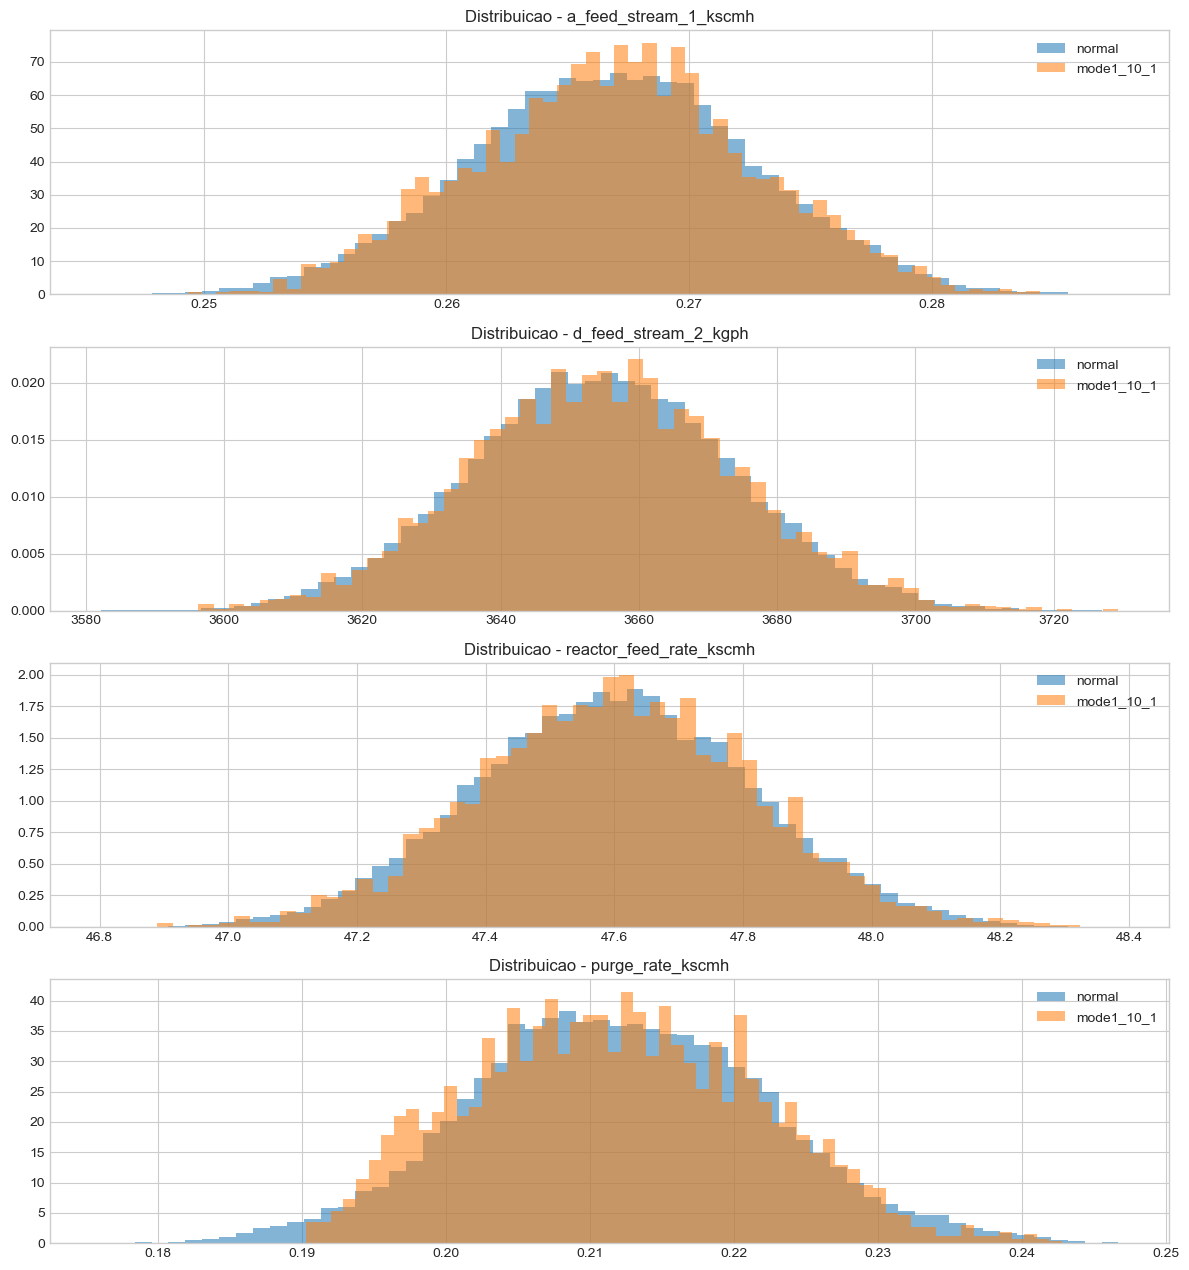

In [12]:
selected_vars = [
    'a_feed_stream_1_kscmh',
    'd_feed_stream_2_kgph',
    'reactor_feed_rate_kscmh',
    'purge_rate_kscmh',
]
selected_vars = [v for v in selected_vars if v in normal_df.columns]

first_fault_name = sorted(fault_dfs.keys())[0]
first_fault_df = fault_dfs[first_fault_name]

fig, axes = plt.subplots(len(selected_vars), 1, figsize=(12, 3.2 * len(selected_vars)), sharex=False)
if len(selected_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, selected_vars):
    ax.hist(normal_df[col], bins=60, alpha=0.55, density=True, label='normal')
    ax.hist(first_fault_df[col], bins=60, alpha=0.55, density=True, label=first_fault_name)
    ax.set_title(f'Distribuicao - {col}')
    ax.legend()

plt.tight_layout()
plt.show()

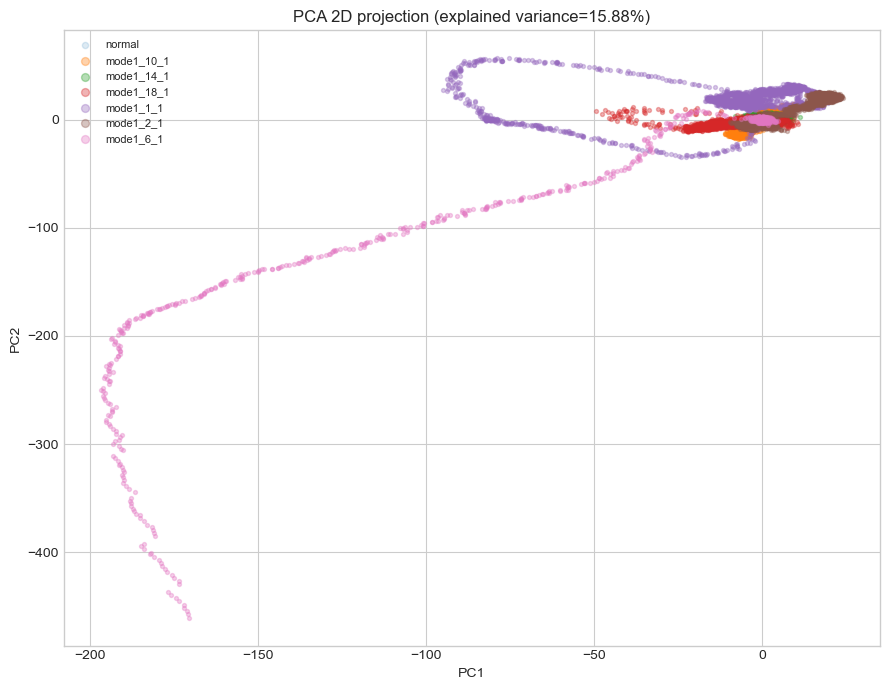

In [15]:
scaler = StandardScaler()
X_normal = scaler.fit_transform(normal_df[feature_cols])

pca2 = PCA(n_components=2, random_state=42)
Z_normal = pca2.fit_transform(X_normal)

plt.figure(figsize=(9, 7))
plt.scatter(Z_normal[:, 0], Z_normal[:, 1], s=5, alpha=0.15, label='normal')

for name in sorted(fault_dfs.keys()):
    X_fault = scaler.transform(fault_dfs[name][feature_cols])
    Z_fault = pca2.transform(X_fault)
    plt.scatter(Z_fault[:, 0], Z_fault[:, 1], s=8, alpha=0.35, label=name)

exp_var = pca2.explained_variance_ratio_.sum()
plt.title(f'PCA 2D projection (explained variance={exp_var:.2%})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

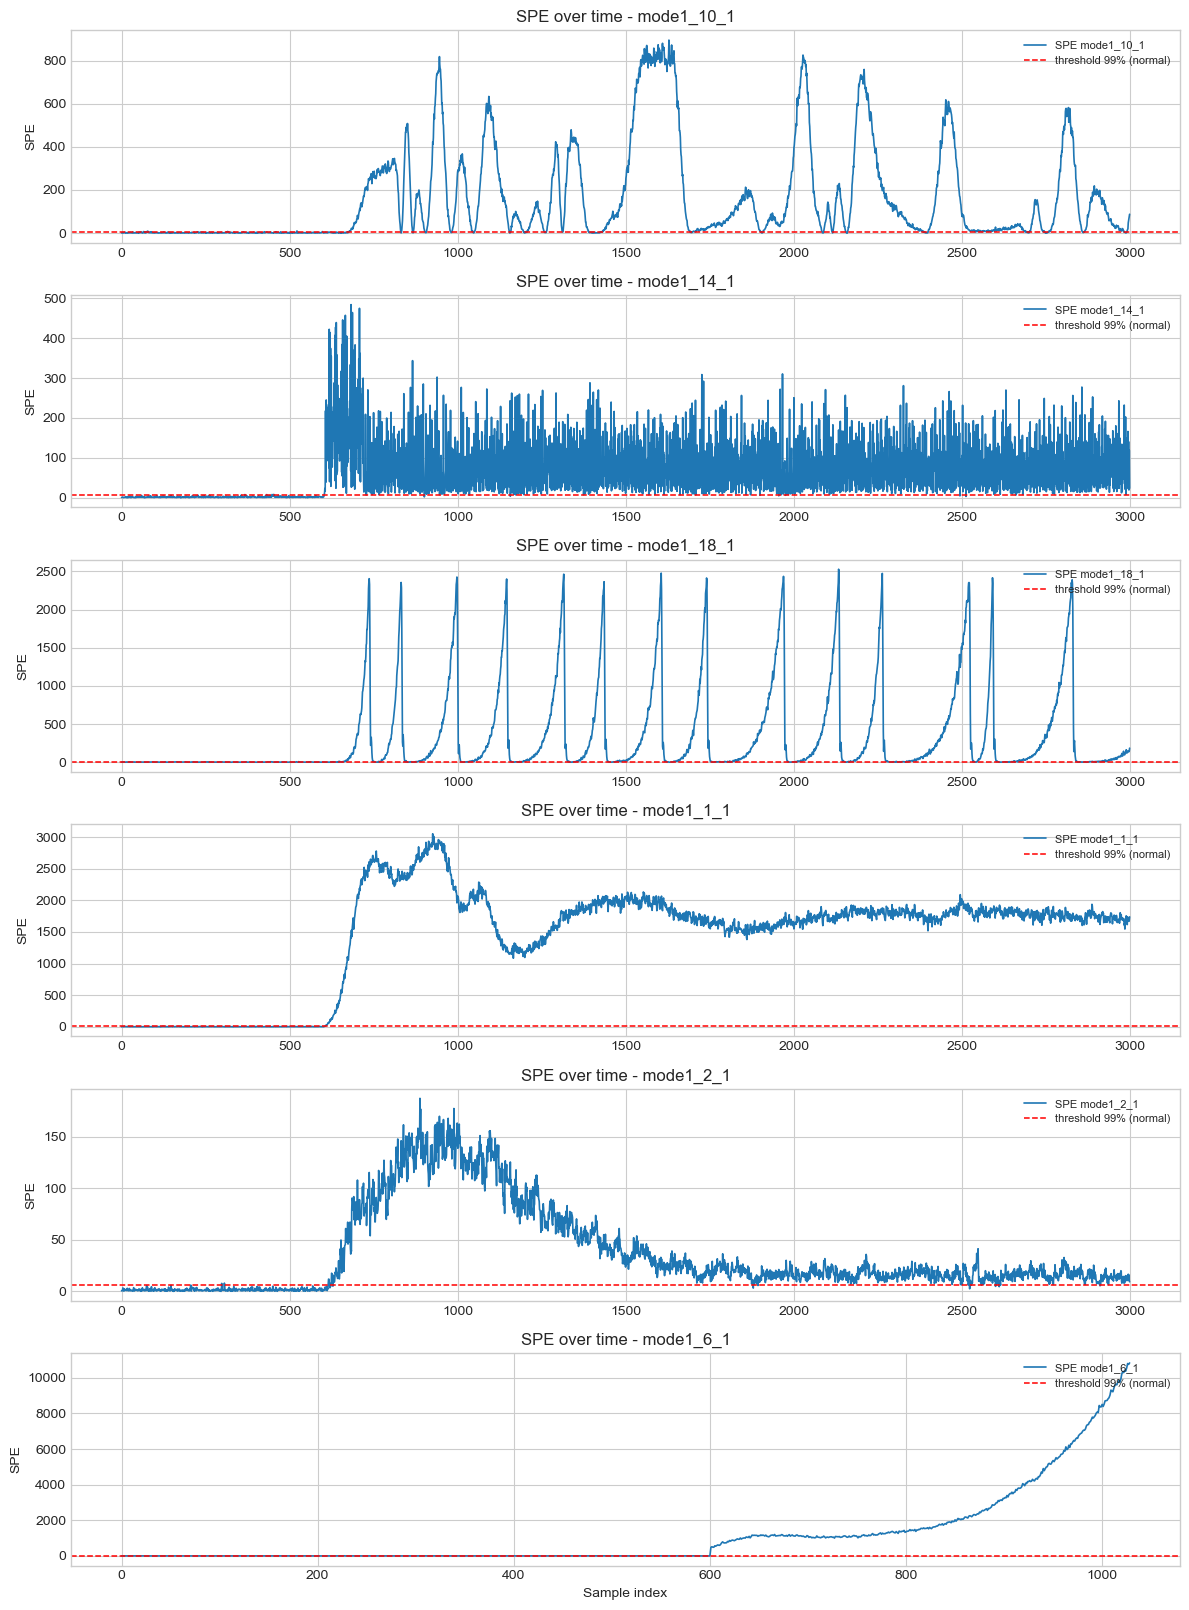

PCA components used (95% variance): 35
SPE threshold (99th percentile of normal): 6.3585


In [16]:
pca_spe = PCA(n_components=0.95, random_state=42)
Xn = scaler.fit_transform(normal_df[feature_cols])
Sn = pca_spe.fit_transform(Xn)
Xn_recon = pca_spe.inverse_transform(Sn)
spe_normal = ((Xn - Xn_recon) ** 2).sum(axis=1)
threshold = float(np.quantile(spe_normal, 0.99))

fig, axes = plt.subplots(len(fault_dfs), 1, figsize=(12, 2.7 * len(fault_dfs)), sharex=False)
if len(fault_dfs) == 1:
    axes = [axes]

for ax, name in zip(axes, sorted(fault_dfs.keys())):
    Xf = scaler.transform(fault_dfs[name][feature_cols])
    Sf = pca_spe.transform(Xf)
    Xf_recon = pca_spe.inverse_transform(Sf)
    spe_fault = ((Xf - Xf_recon) ** 2).sum(axis=1)

    ax.plot(spe_fault, linewidth=1.2, label=f'SPE {name}')
    ax.axhline(threshold, color='r', linestyle='--', linewidth=1.1, label='threshold 99% (normal)')
    ax.set_title(f'SPE over time - {name}')
    ax.set_ylabel('SPE')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()

print(f'PCA components used (95% variance): {pca_spe.n_components_}')
print(f'SPE threshold (99th percentile of normal): {threshold:.4f}')

## Proximos passos sugeridos

1. Escolher uma falha para estudo principal e medir atraso de deteccao.
2. Comparar limiares (95%, 97.5%, 99%) e taxa de falso alarme.
3. Testar selecao de variaveis (somente medidas de processo vs todas as variaveis).
4. Avancar para notebook de treinamento/avaliacao do detector PCA.